In [3]:
import pandas as pd
import numpy as np
import optimization as opt
import matplotlib.pyplot as plt
import geopandas as gpd
import cartopy.crs as ccrs
from cartopy.io import shapereader

shape=gpd.read_file('hexagon_grid.shp')
shape_crs4326 = shape.to_crs(epsg=4326)
countries_polygons = gpd.read_file(shapereader.natural_earth(resolution='10m', category='cultural', name='admin_1_states_provinces'))
germany_extent = [4, 17, 46, 56]

# Management Options

- no-mgmt,
- low-structure = Kahlschlag bzw. Schirmschlag je nachdem ob Laubholz- oder Nadelholz-dominiert
- medium-structure = Femelschlagverfahren (group selection)
- high-structure = Plenter (single tree selection)

Original data has 23232000 rows.

In [4]:
# reading takes 1.5min
iland_cluster6_chunks = pd.read_csv('cluster6_for_Konstantin_hexagon.csv.gz', chunksize=10000)
iland_cluster6 = pd.concat([chunk[(chunk['RCPScenario'] != 'historical') & (chunk['ClimateModel'] == 'ICHEC-EC-EARTH') & (chunk['Replicate'] == 'repl0')] for chunk in iland_cluster6_chunks])

# Optimize a dataframe with multiple GCs

In [7]:
ES = ['abovegroundCarbon', 'shannonIndex', 'evapotranspiration_mm', 'mean_soilwatercontent_mm', 'volumeHarvested']

In [8]:
iland_multiple_gc = iland_cluster6.copy()
iland_multiple_gc = iland_multiple_gc[iland_multiple_gc['decade'] == 8][['rid', 'Germany_id', 'RCPScenario', 'Management'] + ES]
iland_multiple_gc = iland_multiple_gc.set_index(['rid', 'Germany_id', 'RCPScenario', 'Management'])

In [9]:
# TODO: indifference thresholds, checking for 0 division, no "lower is better", add assertions
def normalize(gc_data):
    return (gc_data - gc_data.min()) / (gc_data.max() - gc_data.min())

# sensitivity analysis with this normalization, not per RCP.
# iland_one_gc_normalized = (iland_one_gc - iland_one_gc.min()) / (iland_one_gc.max() - iland_one_gc.min())

def convert_to_optimizer_input(gc_data):
    df_long = gc_data.stack().rename("value")
    df_long.index.set_names(['rid', 'Germany_id', "rcp", "management", "ES"], inplace=True)
    df_long = df_long.reorder_levels(["ES", 'Germany_id', 'rid', "rcp", "management"])
    return df_long.unstack("management")

TOLERANCE = 0.00001

def prepare_and_optimize_gridcell(gc_data):
    normalized_gc_data = gc_data.groupby('RCPScenario', group_keys=False).apply(normalize)

    optimizer_data = convert_to_optimizer_input(normalized_gc_data)

    managements = list(optimizer_data.columns)

    opt_result = opt.solve_optimization_for_gridcell_general_min_max_distance(optimizer_data.values, ['rcp26', 'rcp45', 'rcp85'], es_weights=[0.0, 0.0, 0.0, 0.0, 1.0])

    assert opt_result.success == True, "Optimization failed for gc " + str(gc_data.index.get_level_values('rid')[0])

    portfolio = opt_result.x[1:]
    portfolio[np.abs(portfolio) < TOLERANCE] = 0.0

    portfolio_sum = np.sum(portfolio)
    assert np.abs(portfolio_sum - 1) < TOLERANCE, "Optimization result does not sum to 1 but " + str(portfolio_sum) + " for gc " + str(gc_data.index.get_level_values('rid')[0])
    assert np.all(portfolio >= 0), "negative portfolio values"

    return pd.Series({managements[i]: portfolio[i] for i in range(len(managements))})

def compute_mean_portfolios(grp):
    hexagon_mean_portfolio = grp.mean(axis=0)
    portfolio_sum = hexagon_mean_portfolio.values.sum()
    assert np.abs(portfolio_sum-1) < TOLERANCE, "Averaged portfolio does not sum to 1 but to " + str(portfolio_sum) + " for hexagon " + str(grp.index.get_level_values('Germany_id')[0])
    return hexagon_mean_portfolio

In [10]:
# 1min for 12000 rids, using 1 climate model and 1 replicate
portfolios = iland_multiple_gc.groupby(['rid', 'Germany_id'], group_keys=False).apply(prepare_and_optimize_gridcell)

In [11]:
mean_portfolios = portfolios.groupby('Germany_id').apply(compute_mean_portfolios)

In [48]:
cols = ["high-structure", "low-structure", "medium-structure", "no-mgmt"]
colors = ["orange", "limegreen", "darkgreen", "purple"]
brandenburg_extent = [10.5, 15.5, 51, 54]


def draw_pie_inset(ax, ratios, x, y, size=0.03):
    trans = ax.transData.transform((x, y))
    inv = ax.transAxes.inverted().transform(trans)

    pie_ax = ax.inset_axes([inv[0]-size/2, inv[1]-size/2, size, size])

    pie_ax.pie(
        ratios,
        colors=colors,
        wedgeprops=dict(width=0.75)  # 👈 donut!
    )

    pie_ax.set_aspect('equal')
    pie_ax.axis('off')


def plot_portfolios_on_hexagons(mean_portfolios):
    fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})

    ax.set_extent(brandenburg_extent, crs=ccrs.PlateCarree())
    ax.add_geometries(
        countries_polygons['geometry'], crs=ccrs.PlateCarree(),
        facecolor='none', edgecolor='0.2', linewidth=0.5
    )

    shape_cluster6 = shape_crs4326[
        shape_crs4326["Germany_id"].isin(mean_portfolios.index)
    ]

    num_portfolios = len(mean_portfolios.index)

    shape_cluster6 = shape_cluster6.merge(
        mean_portfolios.reset_index(),
        right_on="Germany_id",
        left_on="Germany_id"
    )

    assert num_portfolios == len(shape_cluster6.index), "merging was not correct!"

    shape_cluster6.plot(ax=ax, alpha=0.3, edgecolor='1.0', linewidth=1.0)

    coords = shape_cluster6.geometry.representative_point()

    for (_, row), point in zip(shape_cluster6.iterrows(), coords):
        draw_pie_inset(ax, row[cols], point.x, point.y, size=0.07)

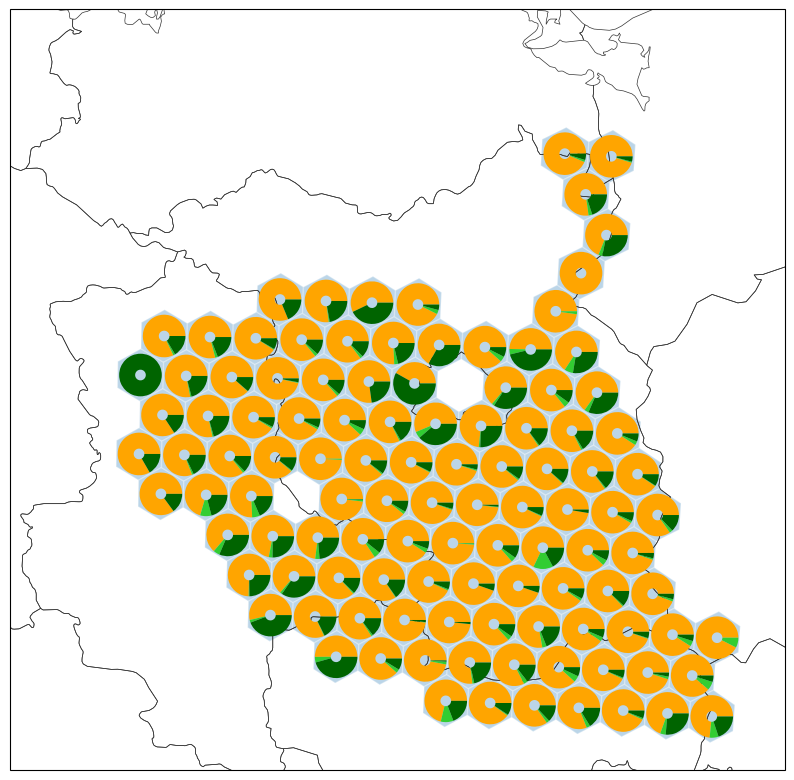

In [49]:
plot_portfolios_on_hexagons(mean_portfolios)

# TODOs for Johannes

- base values --> even for decade == 1 the values differ.
  - obwohl, vllt fuer historical scenario?
- other ESs